In [28]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans,DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("/content/Country-data.csv")

In [3]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [5]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [8]:
print("Missing values: \n",df.isnull().sum())
print("Duplicate Rows: ", df.duplicated().sum())

Missing values: 
 country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64
Duplicate Rows:  0


In [9]:
df.columns

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='object')

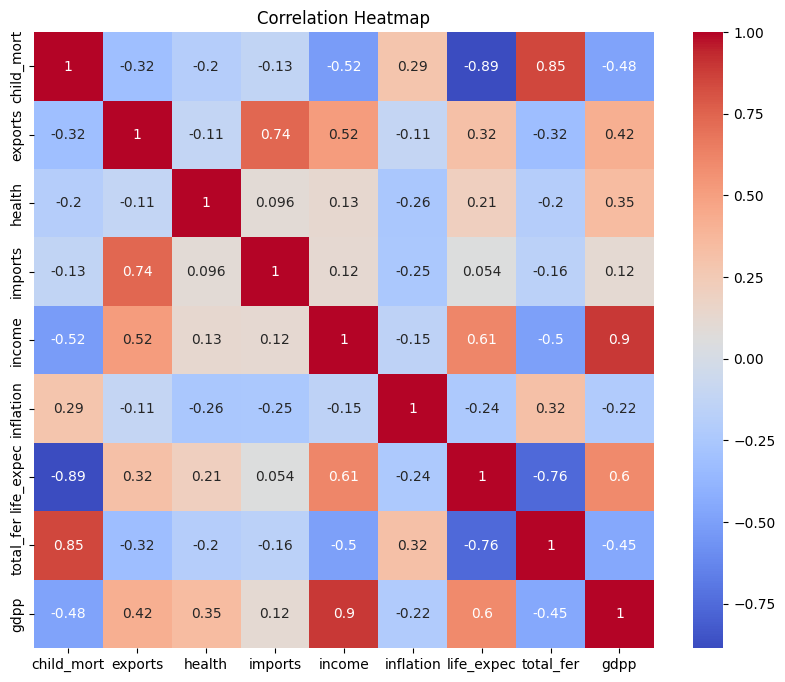

In [10]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [12]:
X = df.drop("country", axis=1)

sc = StandardScaler()
X_scaled = sc.fit_transform(X)
print(X_scaled.shape)

(167, 9)


In [14]:
wcss = []
for i in range(1,11):
    model = KMeans(n_clusters=i, random_state=42)
    model.fit(X_scaled)
    wcss.append(model.inertia_)

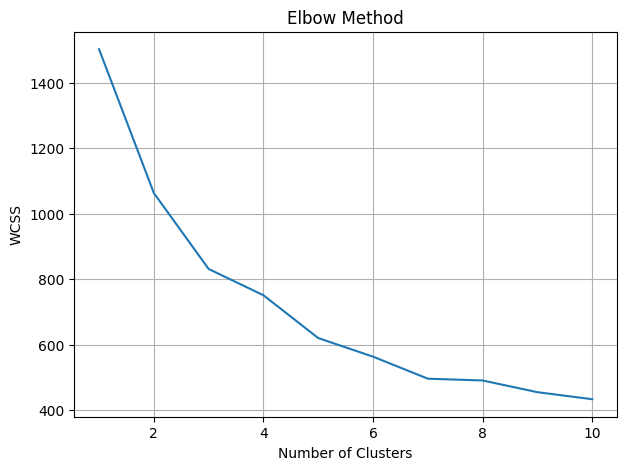

In [15]:
plt.figure(figsize=(7,5))

plt.plot(range(1,11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

In [16]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
df["Cluster"] = clusters

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,2
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,0
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,0
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,2
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,0


In [29]:
sil_score = silhouette_score(X_scaled, clusters)
print(f"Silhouette Score for K-Means (k=3): {sil_score:.4f}")

Silhouette Score for K-Means (k=3): 0.2856


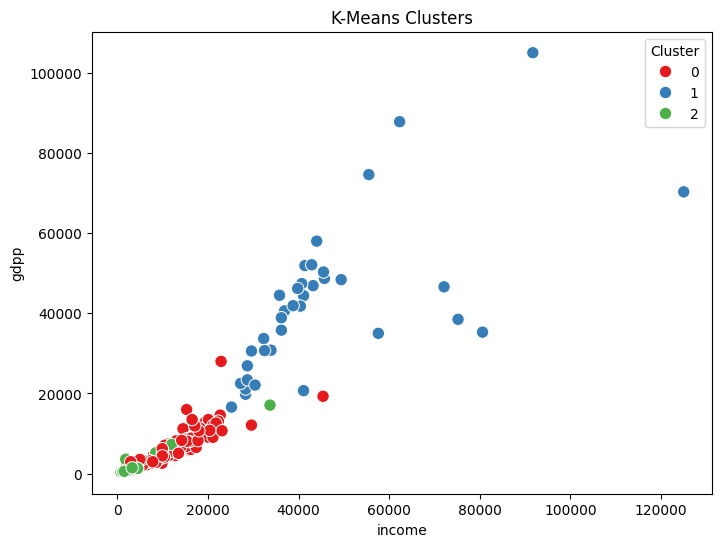

In [30]:
plt.figure(figsize=(8,6))

sns.scatterplot(data=df,x="income",y="gdpp",hue="Cluster",palette="Set1",s=80)

plt.title("K-Means Clusters")
plt.show()

In [31]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)

df["DBSCAN_Cluster"] = db_labels
df[["country", "DBSCAN_Cluster"]].head()

,country,DBSCAN_Cluster
0,Afghanistan,0
1,Albania,0
2,Algeria,0
3,Angola,-1
4,Antigua and Barbuda,0


In [32]:
df['DBSCAN_Cluster'].value_counts()

,count
DBSCAN_Cluster,
0,137
-1,30


In [33]:
pca = PCA(n_components=2)
pca_components = pca.fit_transform(X_scaled)

df['pca_1'] = pca_components[:, 0]
df['pca_2'] = pca_components[:, 1]

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")

Explained variance ratio: [0.4595174  0.17181626]


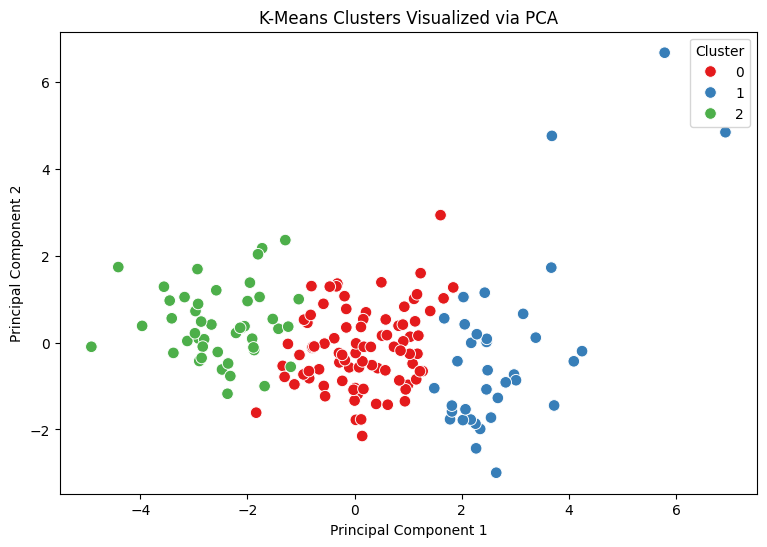

In [35]:
plt.figure(figsize=(9,6))

sns.scatterplot(x='pca_1', y='pca_2',hue='Cluster',palette='Set1',data=df,s=70)
plt.title('K-Means Clusters Visualized via PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

In [36]:
cluster_summary = df.groupby('Cluster')[['child_mort', 'income', 'gdpp', 'life_expec', 'total_fer']].mean()
cluster_summary

,child_mort,income,gdpp,life_expec,total_fer
Cluster,,,,,
0,22.456977,12321.744186,6461.767442,72.566279,2.340349
1,5.000000,45672.222222,42494.444444,80.127778,1.752778
2,95.106667,3539.844444,1766.711111,59.055556,5.065333


## Observations

1. Cluster 2 shows the highest child mortality and lowest income and gdpp values, indicating this group represents low-development countries most in need of aid.
2. Cluster 1 exhibits the highest income, gdpp, and life expectancy combined with the lowest child mortality, marking it as the high-tier developed economic zone.
3. Cluster 0 falls between the two extremes, representing moderately developing countries with mid-range health and economic indicators.
4. Countries in the high-mortality cluster also show elevated total fertility rates, a pattern consistent with lower access to healthcare and education.
5. The PCA scatterplot confirms reasonably well-separated groupings along the first principal component, which appears strongly correlated with overall economic development (income and gdpp).